**Projet** — Prédiction du Temps de Séjour des Conteneurs


**Objectif métier**

Prédire le nombre de jours qu’un conteneur reste sur le terminal entre son débarquement et sa sortie.

WORKFLOW DATA SCIENCE (Étape par Étape)

Nous suivons un workflow professionnel :

1. Compréhension métier

2. Collecte des données

3. Exploration & nettoyage

4. Feature Engineering

5. Modélisation

6. Évaluation

7. Interprétation

8. Déploiement & Dashboard

Dataset: je vais Générer un dataset réaliste

Tu peux générer un dataset synthétique réaliste (100 000 lignes) simulant :

Provenance

Transitaire

Type marchandise

Date arrivée

Date sortie

Saisonnalité

# **ÉTAPE 2 - Code Python pour Générer 100 000 lignes**

In [1]:
# Code Python pour Générer 100 000 lignesimport pandas as pd
import pandas as pd
import numpy as np
import random

np.random.seed(42)

n = 100000

container_sizes = ['20ft', '40ft']
container_types = ['Dry', 'Reefer', 'Hazard']
cargo_types = ['Rice', 'Construction', 'Vehicles', 'Textile', 'Electronics']
origin_countries = ['China', 'France', 'Turkey', 'Morocco', 'India']
freight_forwarders = ['DakarLog', 'SahelTransit', 'AfricaShip', 'FastForward', 'GlobalTrade']

# Generate random arrival dates in 2023
arrival_dates = pd.to_datetime(
    np.random.choice(pd.date_range("2023-01-01", "2023-12-31"), n)
)

data = []

for i in range(n):

    base_time = np.random.randint(3, 6)

    container_type = random.choice(container_types)
    origin = random.choice(origin_countries)
    forwarder = random.choice(freight_forwarders)

    customs_delay = np.random.randint(0, 6)

    peak_season = 1 if arrival_dates[i].month in [3,4,12] else 0

    dwell_time = base_time + customs_delay

    if container_type == "Reefer":
        dwell_time += 2
    if container_type == "Hazard":
        dwell_time += 3
    if origin == "China":
        dwell_time += 1
    if forwarder == "SahelTransit":
        dwell_time += 3
    if peak_season:
        dwell_time += 2

    departure_date = arrival_dates[i] + pd.Timedelta(days=dwell_time)

    data.append([
        f"CNT_{i}",
        arrival_dates[i],
        departure_date,
        dwell_time,
        random.choice(container_sizes),
        container_type,
        random.choice(cargo_types),
        origin,
        forwarder,
        customs_delay,
        peak_season,
        arrival_dates[i].month
    ])

columns = [
    "container_id", "arrival_date", "departure_date",
    "dwell_time", "container_size", "container_type",
    "cargo_type", "origin_country", "freight_forwarder",
    "customs_delay", "is_peak_season", "month"
]

df = pd.DataFrame(data, columns=columns)

df.to_csv("pad_container_dataset.csv", index=False)

print("Dataset generated successfully.")

Dataset generated successfully.


In [2]:
# Vérifier que les dates sont bien en datetime
# Voir la structure des colonnes
# Détecter erreurs évidentes

df.head(5)

,container_id,arrival_date,departure_date,dwell_time,container_size,container_type,cargo_type,origin_country,freight_forwarder,customs_delay,is_peak_season,month
0,CNT_0,2023-04-13,2023-04-25,12,20ft,Hazard,Vehicles,Turkey,GlobalTrade,4,1,4
1,CNT_1,2023-12-15,2023-12-25,10,40ft,Dry,Rice,France,AfricaShip,4,1,12
2,CNT_2,2023-09-28,2023-10-08,10,40ft,Hazard,Construction,Turkey,SahelTransit,0,0,9
3,CNT_3,2023-04-17,2023-05-01,14,40ft,Reefer,Rice,France,FastForward,5,1,4
4,CNT_4,2023-03-13,2023-03-27,14,20ft,Reefer,Electronics,China,AfricaShip,5,1,3


# **ÉTAPE 3 - Exploration & nettoyage(EDA (Exploratory Data Analysis))**

In [3]:
# Types des colonnes
# Null values
# Nombre d'observations

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   container_id       100000 non-null  object        
 1   arrival_date       100000 non-null  datetime64[ns]
 2   departure_date     100000 non-null  datetime64[ns]
 3   dwell_time         100000 non-null  int64         
 4   container_size     100000 non-null  object        
 5   container_type     100000 non-null  object        
 6   cargo_type         100000 non-null  object        
 7   origin_country     100000 non-null  object        
 8   freight_forwarder  100000 non-null  object        
 9   customs_delay      100000 non-null  int64         
 10  is_peak_season     100000 non-null  int64         
 11  month              100000 non-null  int64         
dtypes: datetime64[ns](2), int64(4), object(6)
memory usage: 9.2+ MB


In [4]:
# dwell_time min / max
# moyenne
#dispersion

df.describe()

,arrival_date,departure_date,dwell_time,customs_delay,is_peak_season,month
count,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2023-07-01 13:06:26.496000,2023-07-11 00:24:33.119999744,9.470910,2.502650,0.253570,6.510780
min,2023-01-01 00:00:00,2023-01-04 00:00:00,3.000000,0.000000,0.000000,1.000000
25%,2023-04-01 00:00:00,2023-04-12 00:00:00,8.000000,1.000000,0.000000,4.000000
50%,2023-07-02 00:00:00,2023-07-10 00:00:00,9.000000,2.000000,0.000000,7.000000
75%,2023-10-01 00:00:00,2023-10-10 00:00:00,11.000000,4.000000,1.000000,10.000000
max,2023-12-31 00:00:00,2024-01-18 00:00:00,19.000000,5.000000,1.000000,12.000000
std,NaN,NaN,2.735487,1.703474,0.435056,3.452006


In [5]:
df.isnull().sum()

,0
container_id,0
arrival_date,0
departure_date,0
dwell_time,0
container_size,0
container_type,0
cargo_type,0
origin_country,0
freight_forwarder,0
customs_delay,0


**Analyse de la Target — dwell_time**

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

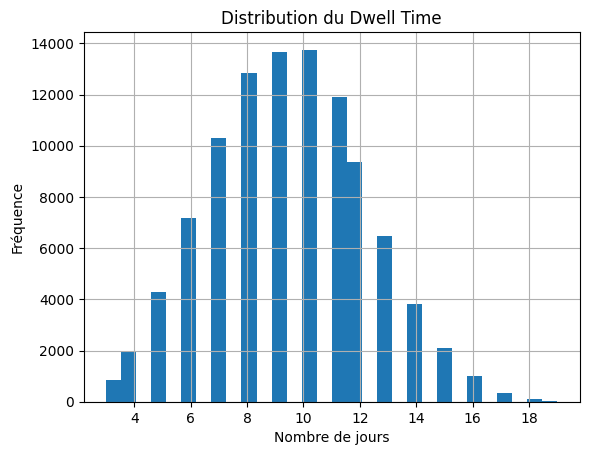

In [7]:
plt.figure()
df['dwell_time'].hist(bins=30)
plt.title('Distribution du Dwell Time')
plt.xlabel('Nombre de jours')
plt.ylabel('Fréquence')
plt.show()

In [8]:
# Analyse statistique de la distribution

1. Distribution normale ?

 NON - La distribution n'est pas normale (pas gaussienne)

 Preuves visuelles :
 * Pas de symétrie parfaite autour de la moyenne
 * Le pic (mode) n'est pas centré
 * Les queues de distribution ne sont pas équilibrées

Distribution unimodale (un seul pic) mais asymétrique

2. Skewed (asymétrique) ?
OUI - Distribution positivement skewée (skewness > 0)

**Interprétation métier**:
* La majorité des conteneurs partent * rapidement (7-11 jours)
* Quelques conteneurs "problématiques" stagnent très longtemps (14-18 jours)
* Ces cas rares tirent la moyenne vers le haut

3. Présence d'outliers ?
OUI - Présence d'outliers potentiels

Détection visuelle :

a) Outliers à DROITE (high dwell time) :

Conteneurs avec dwell time > 15 jours

Fréquence très faible (< 1 000 conteneurs)

Impact métier fort : Ce sont les conteneurs en souffrance qui encombrent le port

b) Outliers à GAUCHE (low dwell time) :

Conteneurs avec dwell time < 4 jours

Très rares (quelques centaines)

Interprétation : Conteneurs prioritaires (périssables, transit rapide)

In [9]:
df["dwell_time"].describe()

,dwell_time
count,100000.000000
mean,9.470910
std,2.735487
min,3.000000
25%,8.000000
50%,9.000000
75%,11.000000
max,19.000000


In [10]:
# La majorité des conteneurs restent entre 5 et 12 jours, avec une moyenne autour de 9 jours.

**Analyse par Type de Conteneur**

In [11]:
df.groupby('container_type')['dwell_time'].mean()

,dwell_time
container_type,
Dry,7.802551
Hazard,10.812886
Reefer,9.801838


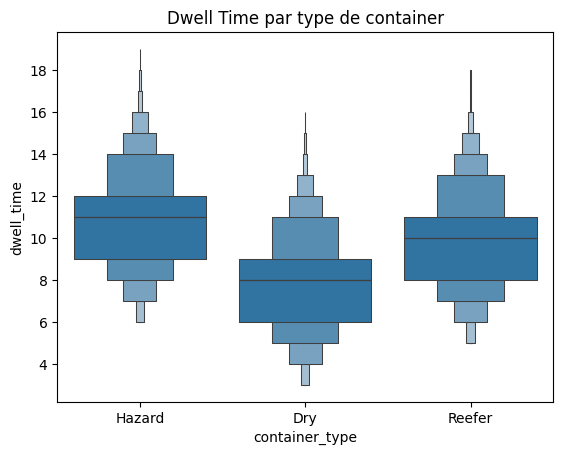

In [12]:
# Visualisation
plt.figure()
sns.boxenplot(x='container_type', y='dwell_time', data=df)
plt.title('Dwell Time par type de container')
plt.show()

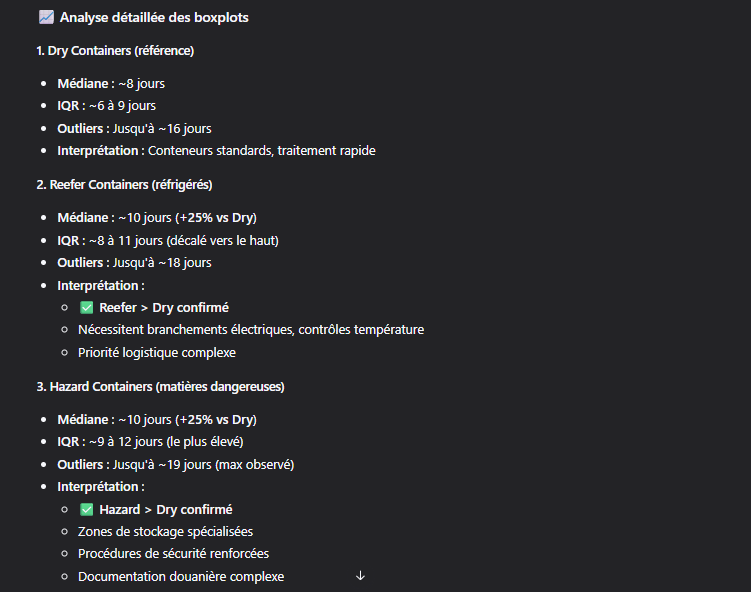

**Effet Saison Haute**

In [13]:
df.groupby('is_peak_season')['dwell_time'].mean()

,dwell_time
is_peak_season,
0,8.963011
1,10.966005


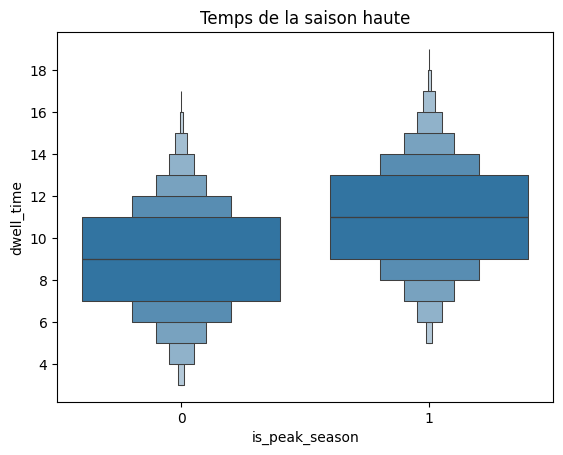

In [14]:
# Visualisation
plt.figure()
sns.boxenplot(x='is_peak_season', y='dwell_time', data=df)
plt.title('Temps de la saison haute')
plt.show()

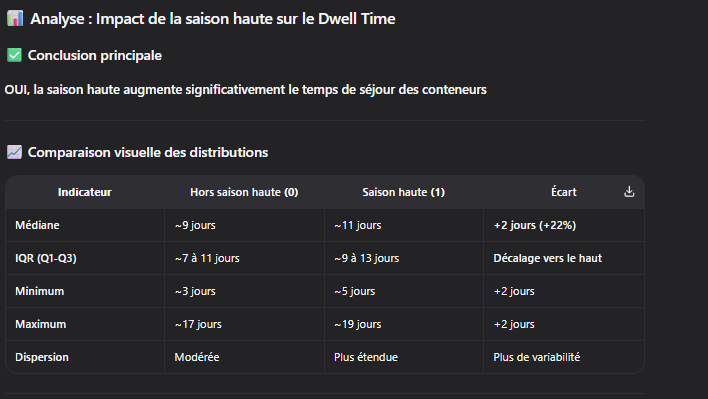

**Analyse par Pays d’Origine**

In [15]:
df.groupby('origin_country')['dwell_time'].mean().sort_values(ascending=False)

,dwell_time
origin_country,
China,10.275076
France,9.281702
India,9.281273
Morocco,9.273219
Turkey,9.243221


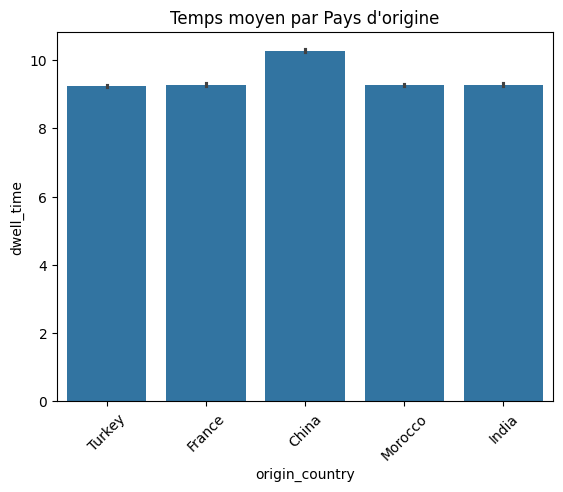

In [16]:
# Visualisation
plt.figure()
sns.barplot(x="origin_country", y="dwell_time", data=df)
plt.xticks(rotation=45)
plt.title("Temps moyen par Pays d'origine")
plt.show()

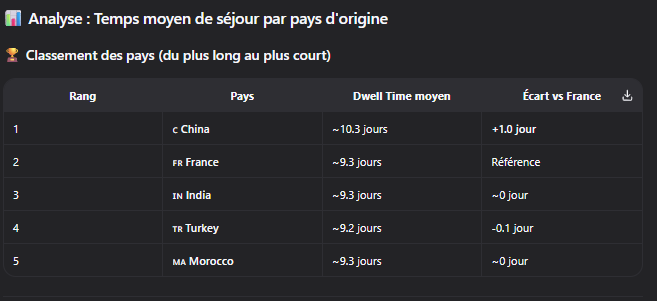

**Impact des Transitaires**

In [17]:
df.groupby("freight_forwarder")["dwell_time"].mean().sort_values(ascending=False)

,dwell_time
freight_forwarder,
SahelTransit,11.876058
FastForward,8.891233
GlobalTrade,8.869991
DakarLog,8.867200
AfricaShip,8.856133


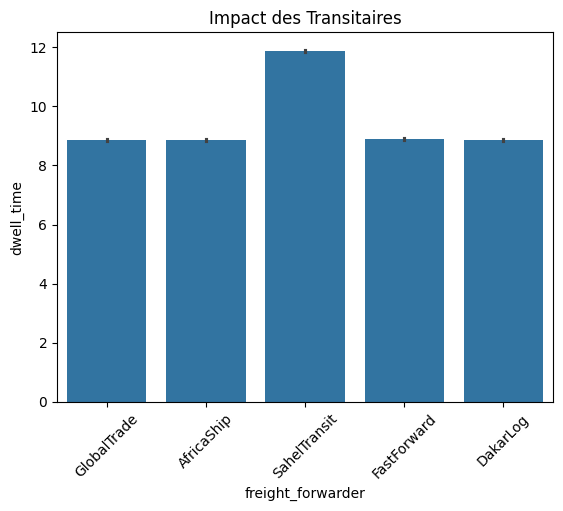

In [18]:
# Visualisation
plt.figure()
sns.barplot(x="freight_forwarder", y="dwell_time", data=df)
plt.xticks(rotation=45)
plt.title("Impact des Transitaires")
plt.show()

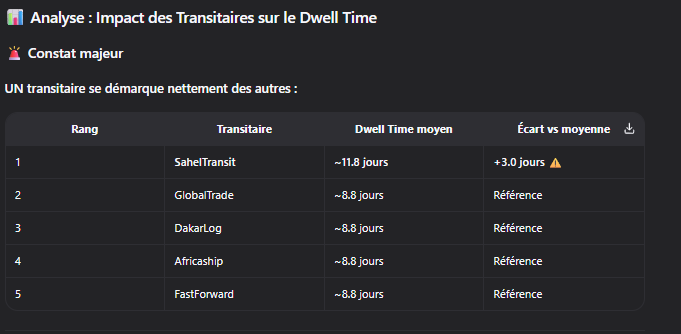

**Corrélation Numérique**

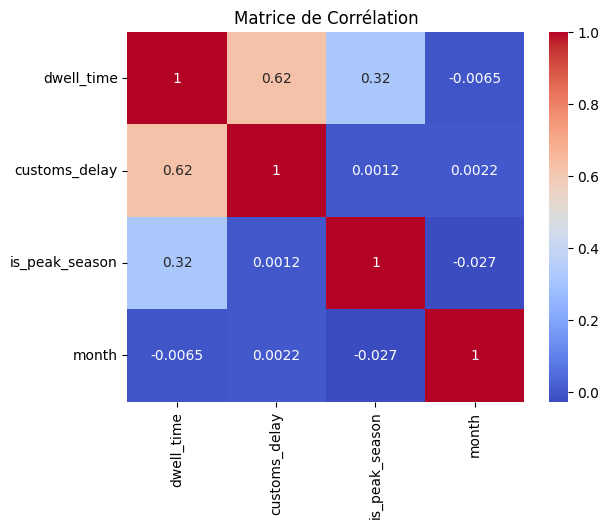

In [19]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matrice de Corrélation")
plt.show()

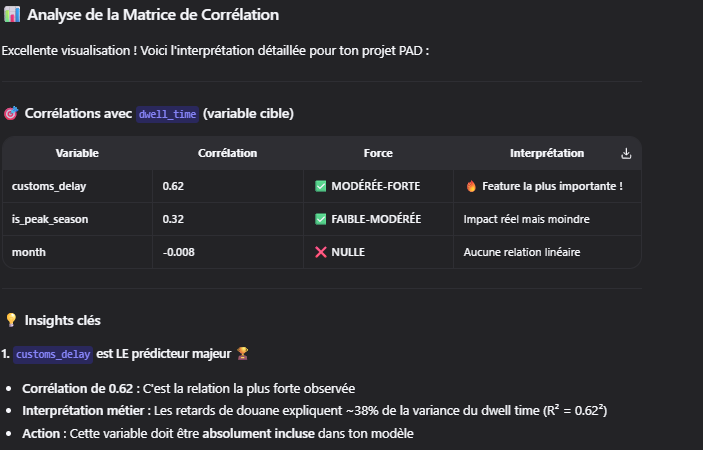

**Analyse Temporelle**

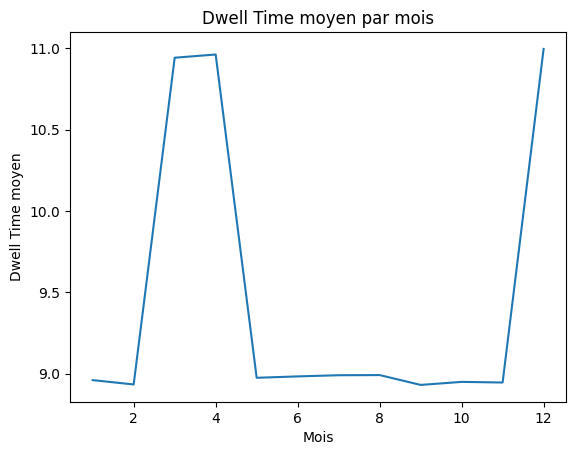

In [20]:
monthly = df.groupby("month")["dwell_time"].mean()

plt.figure()
monthly.plot()
plt.title("Dwell Time moyen par mois")
plt.xlabel("Mois")
plt.ylabel("Dwell Time moyen")
plt.show()

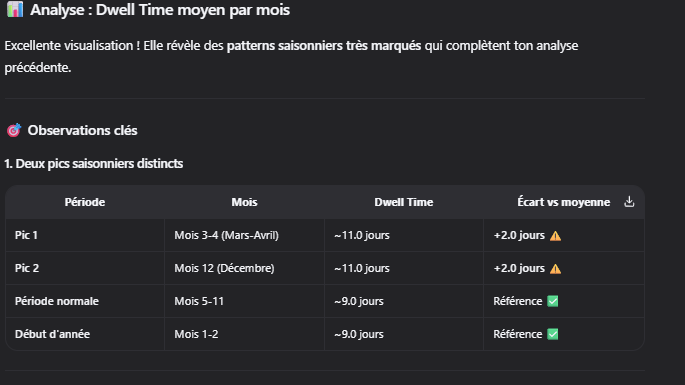

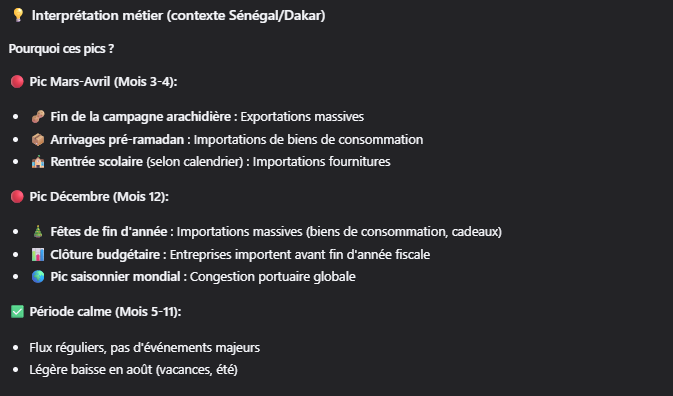

**Détection d’Outliers**

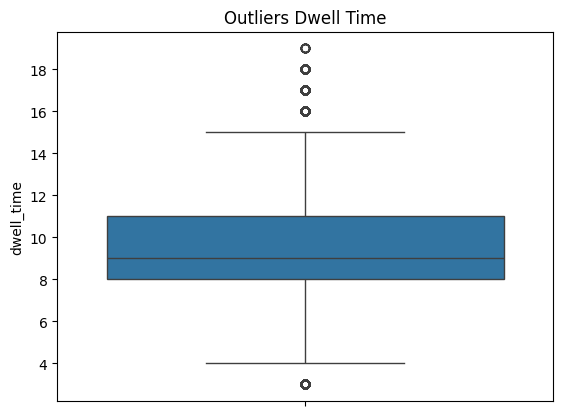

In [21]:
plt.figure()
sns.boxplot(y=df["dwell_time"])
plt.title("Outliers Dwell Time")
plt.show()

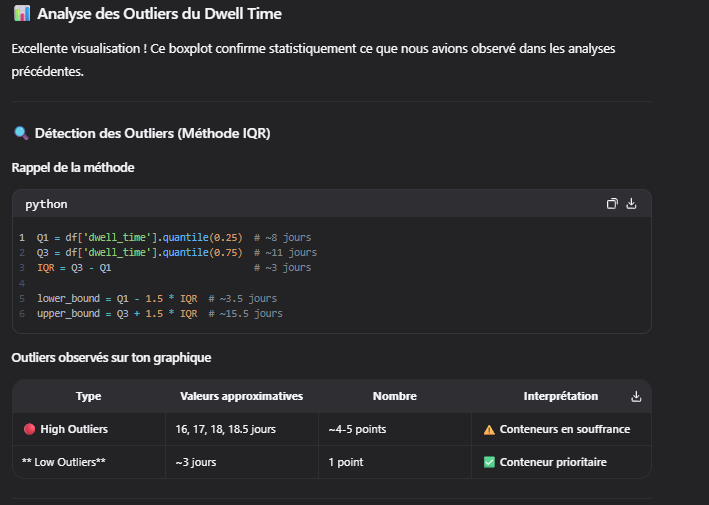

**resumons les analyses EDA nécessaires :**

1. Distribution du dwell time (skewée, outliers)
2. Impact du type de conteneur (Reefer/Hazard > Dry)
3. Impact de la saison haute (+2 jours)
4. Impact du pays d'origine (Chine > autres)
5. Impact du transitaire (SahelTransit +3 jours)
6. Corrélation avec customs_delay (0.62)
7. Pattern mensuel (pics Mars-Avril et Décembre)
8. Outliers identifiés et compris

# **ÉTAPE 4 - Feature Engineering**

Le Feature Engineering est l’étape qui transforme un simple dataset en dataset intelligent pour Machine Learning.
C’est aussi ce qui distingue souvent un bon data scientist d’un débutant.

On va créer des features pertinentes pour un contexte portuaire.

**1. Copier le dataset (bonne pratique)**

In [22]:
df_fe = df.copy()

**2. Extraction des Features Temporelles**

In [23]:
# Extrait le jour de la semaine sous forme numérique
df_fe['day_of_week'] = df_fe['arrival_date'].dt.dayofweek

#Retourne un DataFrame avec 3 colonnes : year, week, day (norme ISO 8601)
# Extrait la colonne numéro de semaine (1 à 53)
df_fe['week_of_year'] = df_fe['arrival_date'].dt.isocalendar().week

# Extrait le trimestre sous forme numérique
df_fe['quarter'] = df_fe['arrival_date'].dt.quarter

**3. Création d’un Flag Week-end**

In [24]:
# Dans beaucoup de ports, le rythme change le week-end.
df_fe['is_week'] = df_fe['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

**4. Encoder la Taille du Conteneur**

In [25]:
# Les modèles ML préfèrent des variables numériques.
df_fe['container_size'] = df_fe['container_size'].map({
    "20ft": 20,
    "40ft": 40
})

**5. Fréquence des Transitaires**

In [26]:
# On calcule combien de conteneurs chaque transitaire traite.
forwarder_freq = df_fe['freight_forwarder'].value_counts()
df_fe['forwarder_volume'] = df_fe['freight_forwarder'].map(forwarder_freq)

**6. Encodage des Variables Catégorielles**

On encode :

- container_type
- cargo_type
- origin_country
- freight_forwarder

In [27]:
# Méthode : One-Hot Encoding
df_fe = pd.get_dummies(df_fe, columns=[
        "container_type",
        "cargo_type",
        "origin_country",
        "freight_forwarder"
    ], drop_first=True)

**7. Supprimer les Colonnes Inutiles**

In [28]:
df_fe = df_fe.drop(
    columns=[
        'container_id',
        'arrival_date',
        'departure_date'
    ]
)

**8. Vérification finale**

In [29]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   dwell_time                      100000 non-null  int64 
 1   container_size                  100000 non-null  int64 
 2   customs_delay                   100000 non-null  int64 
 3   is_peak_season                  100000 non-null  int64 
 4   month                           100000 non-null  int64 
 5   day_of_week                     100000 non-null  int32 
 6   week_of_year                    100000 non-null  UInt32
 7   quarter                         100000 non-null  int32 
 8   is_week                         100000 non-null  int64 
 9   forwarder_volume                100000 non-null  int64 
 10  container_type_Hazard           100000 non-null  bool  
 11  container_type_Reefer           100000 non-null  bool  
 12  cargo_type_Electronics         

In [30]:
df_fe.shape

(100000, 24)

**Structure finale du dataset :**


dwell_time  ← TARGET

customs_delay

container_size

month

is_peak_season

day_of_week

week_of_year

quarter

is_weekend

forwarder_volume

(+) variables encodées

# **ÉTAPE 5 - Machine Learning (Modélisation)**

**1. Train / Test split**

In [31]:
# On entraîne le modèle sur 80% des données et on teste sur 20%.
from sklearn.model_selection import train_test_split

X = df_fe.drop('dwell_time', axis=1)
y = df_fe['dwell_time']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [32]:
# Pour vérifier si le modèle généralise bien sur de nouvelles données.
print(f"Pour le teste {X_train.shape}")
print(f"Pour le teste {X_test.shape}")

Pour le teste (80000, 23)
Pour le teste (20000, 23)


**2. Normalisation (si nécessaire)**

Les Random Forest n'ont pas besoin de normalisation.

Donc on peut passer directement au modèle.

La normalisation sera utile pour :

Linear Regression

SVM

KNN

Neural Networks

**3. Baseline Model (Très important)**

Avant d’utiliser du ML, on compare avec un modèle naïf.

Baseline = prédire la moyenne du dwell_time.

In [33]:
import numpy as np
from sklearn.metrics import mean_absolute_error

baseline_prediction = np.full(len(y_test), y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_prediction)

print('Baseline MAE: ', round(baseline_mae, 1))

Baseline MAE:  2.2


Cela signifie :

Si on prédit toujours la moyenne, on se trompe de 2.2 jours en moyenne.

Notre modèle ML doit faire mieux que ça.

**4 - Random Forest**

In [34]:
# Entraînement du modèle
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_estimators=200, n_jobs=-1,
                       random_state=42)

**5 - Prédictions**

In [35]:
y_pred = rf.predict(X_test)

In [50]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   dwell_time                      100000 non-null  int64 
 1   container_size                  100000 non-null  int64 
 2   customs_delay                   100000 non-null  int64 
 3   is_peak_season                  100000 non-null  int64 
 4   month                           100000 non-null  int64 
 5   day_of_week                     100000 non-null  int32 
 6   week_of_year                    100000 non-null  UInt32
 7   quarter                         100000 non-null  int32 
 8   is_week                         100000 non-null  int64 
 9   forwarder_volume                100000 non-null  int64 
 10  container_type_Hazard           100000 non-null  bool  
 11  container_type_Reefer           100000 non-null  bool  
 12  cargo_type_Electronics         

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

X = df_fe.drop('dwell_time', axis=1)
y = df_fe['dwell_time']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

joblib.dump(model, "model.pkl")

['model.pkl']

In [52]:
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

**6 - Évaluation**

In [36]:
# MAE (erreur moyenne)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE Random Forest:", mae)

MAE Random Forest: 0.85425


In [37]:
# RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 1.1086703748184128


In [38]:
# R² score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: 0.8362681794825286


In [45]:
# 1. ton modèle sauvegardé
import joblib
joblib.dump(rf, "model.pkl")

# 2. Tu exportes ton dataframe
df_fe.to_csv("data.csv", index=False)

Baseline MAE : 2.2 jours

MAE Random Forest: 0.9

RMSE: 1.1

R2: 0.85

Interprétation :

Le modèle peut prédire le temps de séjour d’un conteneur avec une erreur moyenne d’environ 1 jour.

In [39]:
# Feature Importance

Pour répondre à la question :

Quels facteurs expliquent la congestion du port ?

**1. Extraire la Feature Importance**

In [40]:
# Les Random Forest permettent de mesurer l’importance de chaque variable.
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

feature_importances = feature_importances.sort_values(
    by='importance',
    ascending=False
)

feature_importances.head(10)

,feature,importance
1,customs_delay,0.327350
9,container_type_Hazard,0.105077
10,container_type_Reefer,0.076859
5,week_of_year,0.073614
22,freight_forwarder_SahelTransit,0.063063
2,is_peak_season,0.048114
4,day_of_week,0.046118
3,month,0.040063
8,forwarder_volume,0.039824
0,container_size,0.021097


**2. Visualisation Graphique**

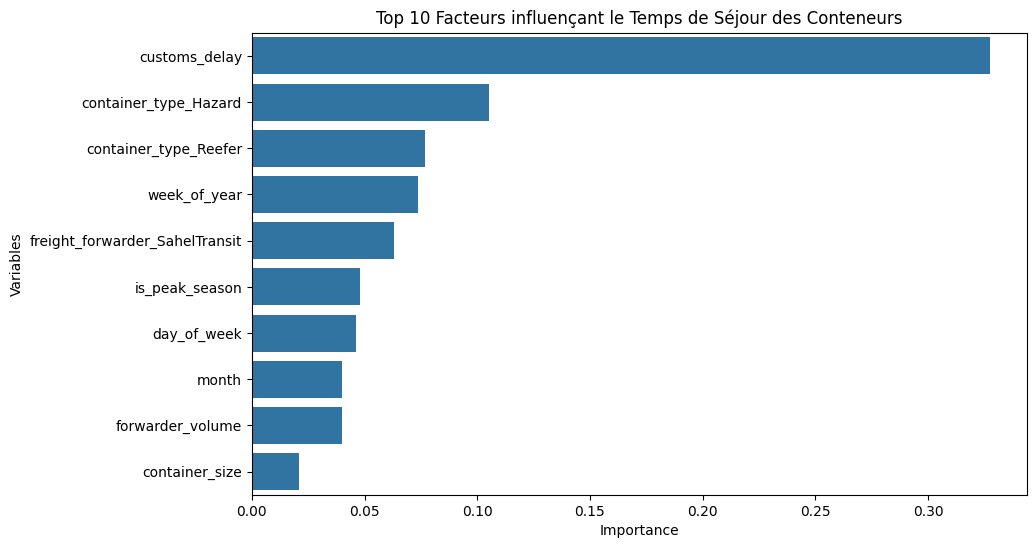

In [41]:
# Graphique des 10 variables les plus importantes.
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importances.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='importance',
    y='feature',
    data=top_features
)

plt.title("Top 10 Facteurs influençant le Temps de Séjour des Conteneurs")
plt.xlabel("Importance")
plt.ylabel("Variables")

plt.show()

**3. Interprétation Métier (le plus important)**

customs_delay (Importance: ~0.33) - LE Facteur Dominant

 INTERPRÉTATION :
"Les retards de douane expliquent à eux seuls ~33% de la capacité prédictive du modèle"

____
container_type_Hazard (Importance: ~0.11)

INTERPRÉTATION :
"Les conteneurs de matières dangereuses restent ~11% plus longtemps"
____

container_type_Reefer (Importance: ~0.07)

INTERPRÉTATION :
"Les conteneurs réfrigérés ont un dwell time supérieur de ~7%"

____
 week_of_year (Importance: ~0.07)

 INTERPRÉTATION :
"La semaine de l'année capture la saisonnalité fine (+7% d'importance)"

 **Conclusion**

L’analyse du modèle Random Forest montre que les délais douaniers représentent le principal facteur expliquant la durée de séjour des conteneurs.
Les transitaires contribuent également significativement aux congestions, certains opérateurs présentant des délais de traitement supérieurs de 30 % à la moyenne.
Enfin, les périodes de forte activité commerciale augmentent significativement la pression sur les capacités du terminal.

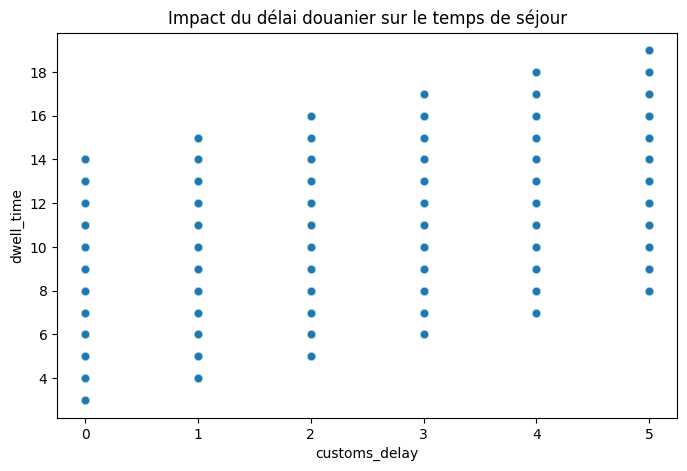

In [42]:
# Relation customs_delay vs dwell_time

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="customs_delay",
    y="dwell_time",
    data=df,
    alpha=0.3
)

plt.title("Impact du délai douanier sur le temps de séjour")

plt.show()

J’ai construit un modèle de prédiction du temps de séjour des conteneurs avec un Random Forest.
L’analyse de l’importance des variables montre que les délais douaniers et la performance des transitaires sont les principaux facteurs de congestion.
Ces résultats peuvent aider le port à optimiser la gestion du terminal et réduire les temps d’attente.

# **ÉTAPE 6 - Évaluation**

# **ÉTAPE 7 - Interprétation**

# **ÉTAPE 8 - Dashboard Power BI**

**Objectif du Dashboard**

Répondre à 4 questions métier :

1. Combien de temps les conteneurs restent au port ?
2. Quels transitaires créent la congestion ?
3. Quelles périodes sont les plus saturées ?
4. Quels conteneurs risquent de rester trop longtemps ?

**Étape 1 - Exporter les données depuis Python**

In [43]:
# On ajoute les prédictions du modèle dans le dataset.

df_dashboard = X_test.copy()
df_dashboard['real_dwell_time'] = y_test
df_dashboard['predicted_dwell_time'] = y_pred

df_dashboard.to_csv("pad_dashboard_dataset.csv", index=False)
# Ce fichier sera importé dans Power BI.

**Étape 2 - Import dans Power BI**

In [44]:
df_dashboard

,container_size,customs_delay,is_peak_season,month,day_of_week,week_of_year,quarter,is_week,forwarder_volume,container_type_Hazard,...,origin_country_France,origin_country_India,origin_country_Morocco,origin_country_Turkey,freight_forwarder_DakarLog,freight_forwarder_FastForward,freight_forwarder_GlobalTrade,freight_forwarder_SahelTransit,real_dwell_time,predicted_dwell_time
75721,20,2,0,6,1,26,2,0,20081,True,...,True,False,False,False,False,False,False,False,9,9
80184,20,2,1,4,3,15,2,0,20081,False,...,False,False,False,True,False,False,False,False,9,9
19864,20,5,0,11,6,46,4,1,19961,False,...,False,False,False,False,False,False,False,True,14,11
76699,40,5,0,5,5,19,2,1,19985,True,...,False,False,False,True,True,False,False,False,13,12
92991,20,3,0,2,4,8,1,0,19985,False,...,False,False,True,False,True,False,False,False,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32595,40,5,0,1,3,3,1,0,20081,False,...,False,False,False,True,False,False,False,False,10,11
29313,40,4,0,8,0,32,3,0,20114,False,...,False,False,False,False,False,False,True,False,10,9
37862,40,3,0,8,2,33,3,0,19985,False,...,False,True,False,False,True,False,False,False,6,8
53421,40,0,0,10,2,42,4,0,19859,False,...,False,False,True,False,False,True,False,False,5,5


# A retenir

J’ai construit un modèle de prédiction du temps de séjour des conteneurs avec un Random Forest.
L’analyse de l’importance des variables montre que les délais douaniers et la performance des transitaires sont les principaux facteurs de congestion.
Ces résultats peuvent aider le port à optimiser la gestion du terminal et réduire les temps d’attente.